/tmp/ipykernel_3460996/2348390430.py:72: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3460996/2348390430.py:72: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3460996/2348390430.py:72: UserWarning: Glyph 25918 (\N{CJK UNIFIED IDEOGRAPH-653E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3460996/2348390430.py:72: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3460996/2348390430.py:72: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


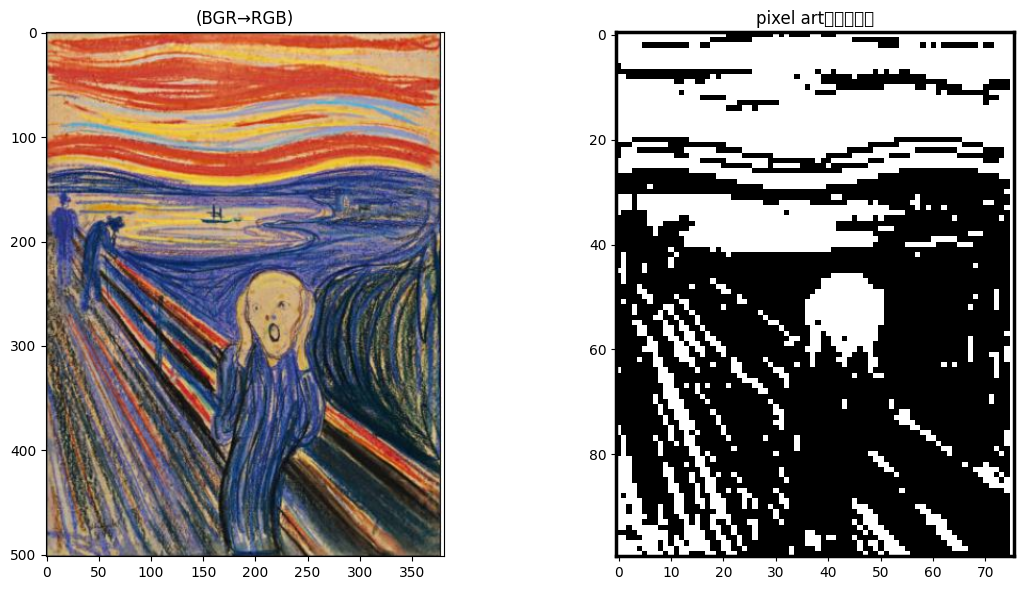

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def blocky_binarize(
    gray, target_blocks_h=100, use_otsu=True, thresh=128, invert=True, blur_ksize=3
):
    """
    灰階 -> (可選)模糊 -> 區塊平均縮小 -> 二值化
    不放大回原尺寸，直接回傳小矩陣（右圖會像投影片，軸到 ~100）
    """
    if blur_ksize and blur_ksize > 0:
        gray = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)

    H, W = gray.shape
    # 依高度決定區塊大小，使縮小後高度 ~ target_blocks_h（例如投影片約 0~100）
    block_size = max(1, H // target_blocks_h)
    dw, dh = max(1, W // block_size), max(1, H // block_size)

    # 區塊平均：INTER_AREA 縮小
    small = cv2.resize(gray, (dw, dh), interpolation=cv2.INTER_AREA)

    # 二值化：Otsu 或手動 threshold
    if use_otsu:
        _, small_bin = cv2.threshold(small, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, small_bin = cv2.threshold(small, thresh, 255, cv2.THRESH_BINARY)

    if invert:
        small_bin = 255 - small_bin

    return small_bin  # 小尺寸，不放大


# ======= 主程式 =======
# 1) 讀圖（BGR）
img = cv2.imread("test.png")  # 換成你的路徑
if img is None:
    raise ValueError("讀不到圖片，請確認路徑")

# 2) 轉灰階
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3) 產生「投影片風格」右圖（高度大約 100 格）
pixel_grid = blocky_binarize(
    gray,
    target_blocks_h=100,  # 控制右圖軸範圍；你可改 80~120 微調
    use_otsu=True,
    invert=False,  # 黑底白點更像投影片截圖
    blur_ksize=3,
)

# 4) 並排顯示：左原圖、右方塊二值圖（右圖不放大）
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 左：原圖（BGR->RGB），保留座標軸
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("(BGR→RGB)")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

# 右：維持小矩陣、nearest 顯示方塊；保留座標軸
im = axes[1].imshow(pixel_grid, cmap="gray", interpolation="nearest")
axes[1].set_title("pixel art（不放大）")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
# 讓外框更粗，視覺更像投影片
for spine in axes[1].spines.values():
    spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()